**Name :Adnan Mushtaq**\
**REG no.:- 12313158**\
**Section :-K23UP**

# **Import libraries**


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


**Load dataset**

In [3]:
df = pd.read_csv("/content/Amazon_Flipkart_EDA_2023_Months.csv")

In [101]:
df['Timestamp'].head()


,Timestamp
0,2023/02/16 09:37:33 AM GMT+5:30
1,2023/09/06 10:23:45 AM GMT+5:30
2,2023/06/06 09:54:56 PM GMT+5:30
3,2023/05/07 09:59:35 AM GMT+5:30
4,2023/07/08 02:25:28 PM GMT+5:30


**Shape of dataset**

In [68]:
print("Shape:", df.shape)


Shape: (12000, 16)


**BASIC DATASET OVERVIEW**

This step helps understand the size of the dataset, data types of variables, and basic
statistical properties such as mean, median, and distribution spread.


In [71]:
df.dtypes


,0
Order_ID,object
Timestamp,object
age,int64
Gender,object
Purchase_Frequency,object
Purchase_Categories,object
Product_Price,float64
Discount_Percent,int64
Final_Price,float64
Quantity,int64


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Order_ID               12000 non-null  object 
 1   Timestamp              12000 non-null  object 
 2   age                    12000 non-null  int64  
 3   Gender                 12000 non-null  object 
 4   Purchase_Frequency     12000 non-null  object 
 5   Purchase_Categories    12000 non-null  object 
 6   Product_Price          12000 non-null  float64
 7   Discount_Percent       12000 non-null  int64  
 8   Final_Price            12000 non-null  float64
 9   Quantity               12000 non-null  int64  
 10  Revenue                12000 non-null  float64
 11  Delivery_Time          12000 non-null  int64  
 12  Customer_Rating        11384 non-null  float64
 13  Customer_Location      11389 non-null  object 
 14  Browsing_Frequency     12000 non-null  object 
 15  Pr

In [102]:
df['Timestamp'] = df['Timestamp'].str.replace(r'\sGMT.*', '', regex=True)


In [103]:
df.head()

,Order_ID,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Product_Price,Discount_Percent,Final_Price,Quantity,Revenue,Delivery_Time,Customer_Rating,Customer_Location,Browsing_Frequency,Product_Search_Method
0,ORD000001,2023/02/16 09:37:33 AM,23,Female,Less than once a month,Beauty and Personal Care;others,29.70,10,26.73,1,26.73,4,NaN,NaN,Few times a month,Keyword
1,ORD000002,2023/09/06 10:23:45 AM,33,Others,Few times a month,Clothing and Fashion,23.40,20,18.72,2,37.44,3,4.0,Karnataka,Few times a month,others
2,ORD000003,2023/06/06 09:54:56 PM,34,Female,Once a week,Clothing and Fashion,44.71,25,33.53,1,33.53,2,3.0,Karnataka,Few times a week,Keyword
3,ORD000004,2023/05/07 09:59:35 AM,25,Male,Less than once a month,others,76.90,10,69.21,3,207.63,5,3.0,West Bengal,Few times a month,Keyword
4,ORD000005,2023/07/08 02:25:28 PM,36,Female,Once a month,Home and Kitchen;others,54.94,30,38.46,1,38.46,3,5.0,NaN,Multiple times a day,Keyword


In [104]:
df['Timestamp'] = pd.to_datetime(
    df['Timestamp'],
    format='%Y/%m/%d %I:%M:%S %p',
    errors='coerce'
)


In [105]:
df['Timestamp'].dtype
df['Timestamp'].isna().sum()


np.int64(0)

Summary statistics of numerical columns

In [ ]:
df.describe()

,age,Product_Price,Discount_Percent,Final_Price,Quantity,Revenue,Delivery_Time,Customer_Rating
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11384.000000
mean,30.882833,41.765730,18.445000,34.061106,1.869667,63.272203,3.787917,3.255885
std,10.232961,32.167013,11.581659,26.921024,1.601737,86.279406,3.037632,1.207083
min,3.000000,1.940000,0.000000,1.340000,1.000000,1.340000,0.000000,1.000000
25%,23.000000,20.487500,10.000000,16.317500,1.000000,21.260000,3.000000,2.000000
50%,27.000000,32.840000,20.000000,26.540000,1.000000,37.980000,4.000000,3.000000
75%,36.000000,52.470000,25.000000,42.745000,2.000000,72.485000,5.000000,4.000000
max,67.000000,337.780000,70.000000,298.840000,10.000000,2089.200000,60.000000,5.000000


### Transposed DataFrame
We transpose the dataset to flip rows and columns, making it easier to quickly inspect column values.


In [ ]:
df_transposed = df.T
df_transposed

,0,1,2,3,4,5,6,7,8,9,...,11990,11991,11992,11993,11994,11995,11996,11997,11998,11999
Order_ID,ORD000001,ORD000002,ORD000003,ORD000004,ORD000005,ORD000006,ORD000007,ORD000008,ORD000009,ORD000010,...,ORD011991,ORD011992,ORD011993,ORD011994,ORD011995,ORD011996,ORD011997,ORD011998,ORD011999,ORD012000
Timestamp,2023/02/16 09:37:33 AM GMT+5:30,2023/09/06 10:23:45 AM GMT+5:30,2023/06/06 09:54:56 PM GMT+5:30,2023/05/07 09:59:35 AM GMT+5:30,2023/07/08 02:25:28 PM GMT+5:30,2023/01/01 08:49:49 PM GMT+5:30,2023/10/01 04:25:49 PM GMT+5:30,2023/06/07 03:00:03 PM GMT+5:30,2023/02/01 12:30:22 PM GMT+5:30,2023/04/14 05:09:31 PM GMT+5:30,...,2023/05/11 05:53:11 PM GMT+5:30,2023/06/18 03:29:26 AM GMT+5:30,2023/01/25 10:38:16 PM GMT+5:30,2023/08/14 10:16:22 PM GMT+5:30,2023/06/23 03:56:57 PM GMT+5:30,2023/04/01 05:32:09 PM GMT+5:30,2023/12/26 10:56:58 PM GMT+5:30,2023/06/23 08:20:42 PM GMT+5:30,2023/07/16 12:57:05 AM GMT+5:30,2023/01/28 09:54:40 AM GMT+5:30
age,23,33,34,25,36,64,27,56,46,43,...,24,16,34,34,23,37,21,23,26,40
Gender,Female,Others,Female,Male,Female,Male,Male,Prefer not to say,Female,Male,...,Prefer not to say,Male,Female,Female,Female,Prefer not to say,Others,Female,Female,Female
Purchase_Frequency,Less than once a month,Few times a month,Once a week,Less than once a month,Once a month,Once a week,Once a month,Once a week,Once a week,Less than once a month,...,Once a month,Once a month,Few times a month,Once a week,Multiple times a week,Once a week,Multiple times a week,Less than once a month,Few times a month,Few times a month
Purchase_Categories,Beauty and Personal Care;others,Clothing and Fashion,Clothing and Fashion,others,Home and Kitchen;others,Groceries and Gourmet Food,others,Clothing and Fashion,others,Groceries and Gourmet Food;Home and Kitchen,...,Clothing and Fashion;Home and Kitchen,Clothing and Fashion;others,Clothing and Fashion,Clothing and Fashion,Beauty and Personal Care,Groceries and Gourmet Food;Beauty and Personal...,Groceries and Gourmet Food;Beauty and Personal...,others,Beauty and Personal Care;Clothing and Fashion,Beauty and Personal Care;Clothing and Fashion;...
Product_Price,29.7,23.4,44.71,76.9,54.94,63.12,21.96,33.02,22.17,35.69,...,51.53,66.67,23.67,88.53,41.71,6.97,29.03,29.33,70.53,22.05
Discount_Percent,10,20,25,10,30,30,10,50,20,10,...,10,25,15,20,0,25,10,20,25,5
Final_Price,26.73,18.72,33.53,69.21,38.46,44.18,19.76,16.51,17.74,32.12,...,46.38,50.0,20.12,70.82,41.71,5.23,26.13,23.46,52.9,20.95
Quantity,1,2,1,3,1,1,1,1,1,1,...,1,1,3,1,2,4,2,1,2,1


**Checking for any duplicated records**

In [ ]:
df.duplicated().sum()

np.int64(0)

**Missing values check**

In [108]:
df.isnull().sum()


,0
Order_ID,0
Timestamp,0
age,0
Gender,0
Purchase_Frequency,0
Purchase_Categories,0
Product_Price,0
Discount_Percent,0
Final_Price,0
Quantity,0


The dataset contains missing values in both numerical and categorical variables.
Each feature requires a different handling strategy based on its nature and relevance
to customer behavior analysis.


check the customer_rating variable

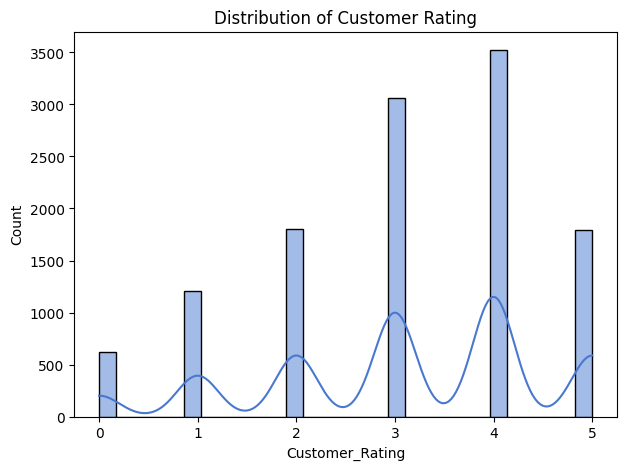

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df['Customer_Rating'], kde=True)
plt.title("Distribution of Customer Rating")
plt.show()


In [55]:
df['Customer_Rating'].mean(), df['Customer_Rating'].median()


(np.float64(3.2558854532677444), 3.0)

In [ ]:
df['Customer_Rating'].skew()


np.float64(-0.517111364698189)

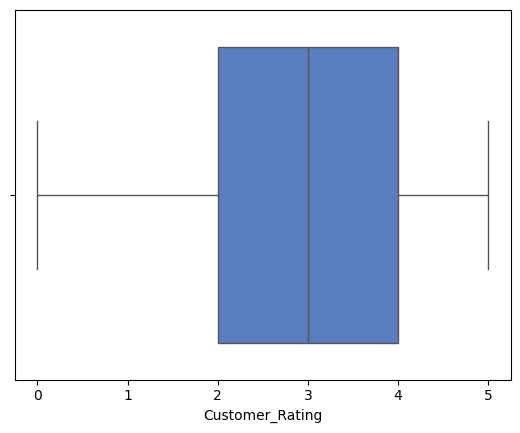

In [ ]:
sns.boxplot(x=df['Customer_Rating'])
plt.show()


Customer_Rating showed a mildly skewed distribution and represents an ordinal scale
of user feedback. To avoid the influence of skewness and preserve the interpretability
of ratings, missing values were imputed using the median rather than the mean.


# **Imputation**

Customer_rating

In [112]:
df['Customer_Rating'] = df['Customer_Rating'].fillna(df['Customer_Rating'].median())


In [84]:
df['Customer_Rating'].isnull().sum()


np.int64(0)

In [64]:
df.head()

,Order_ID,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Product_Price,Discount_Percent,Final_Price,Quantity,Revenue,Delivery_Time,Customer_Rating,Customer_Location,Browsing_Frequency,Product_Search_Method
0,ORD000001,NaT,23,Female,Less than once a month,Beauty and Personal Care;others,29.70,10,26.73,1,26.73,4,3.0,Unknown,Few times a month,Keyword
1,ORD000002,NaT,33,Others,Few times a month,Clothing and Fashion,23.40,20,18.72,2,37.44,3,4.0,Karnataka,Few times a month,others
2,ORD000003,NaT,34,Female,Once a week,Clothing and Fashion,44.71,25,33.53,1,33.53,2,3.0,Karnataka,Few times a week,Keyword
3,ORD000004,NaT,25,Male,Less than once a month,others,76.90,10,69.21,3,207.63,5,3.0,West Bengal,Few times a month,Keyword
4,ORD000005,NaT,36,Female,Once a month,Home and Kitchen;others,54.94,30,38.46,1,38.46,3,5.0,Unknown,Multiple times a day,Keyword


Customer_location

In [111]:
df['Customer_Location'] = df['Customer_Location'].fillna('Unknown')


In [82]:
df['Customer_Location'].isnull().sum()


np.int64(0)

In [63]:
df['Customer_Location'].head()

,Customer_Location
0,Unknown
1,Karnataka
2,Karnataka
3,West Bengal
4,Unknown


Customer_Location is a categorical variable with a large number of missing values.
To avoid data loss and prevent bias towards a single location, missing entries were
labeled as 'Unknown'.

Product_Search_Method

In [110]:
df['Product_Search_Method'] = df['Product_Search_Method'].fillna('Unknown')


In [78]:
df['Product_Search_Method'].isnull().sum()

np.int64(0)

In [113]:
df.isnull().sum()

,0
Order_ID,0
Timestamp,0
age,0
Gender,0
Purchase_Frequency,0
Purchase_Categories,0
Product_Price,0
Discount_Percent,0
Final_Price,0
Quantity,0


All missing values were handled using feature-appropriate strategies, and the timestamp
column was successfully converted to a datetime format after resolving format and
timezone inconsistencies. The dataset is now clean and ready for exploratory analysis.


**OUTLIER DETECTION**

Delivery Time

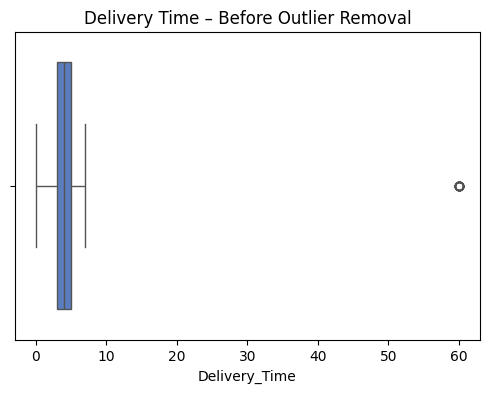

In [114]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Delivery_Time'])
plt.title("Delivery Time – Before Outlier Removal")
plt.show()


The Interquartile Range (IQR) method is a robust statistical technique used to detect
outliers in numerical data. It focuses on the middle portion of the dataset, making it
less sensitive to extreme values and skewed distributions, which are common in real-world
e-commerce data.

The method divides the data into four equal parts called quartiles. The first quartile
(Q1) represents the value below which 25% of the data lies, while the third quartile (Q3)
represents the value below which 75% of the data lies. The difference between Q3 and Q1
is known as the Interquartile Range (IQR), which captures the spread of the central 50%
of the data.

Using the IQR, an acceptable range of values is defined. Any data point that lies below
Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR is considered an outlier. These values are unusually
small or large compared to the majority of observations and may represent anomalies,
measurement errors, or rare extreme cases.

In this analysis, the IQR method was chosen because it does not assume a normal
distribution and is well-suited for skewed behavioral variables such as delivery time.
Removing outliers using this approach helps reduce the influence of extreme values while
preserving realistic customer behavior patterns.


In [115]:
Q1 = df['Delivery_Time'].quantile(0.25)
Q3 = df['Delivery_Time'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound


(np.float64(0.0), np.float64(8.0))

Outliers in Delivery_Time were identified using the interquartile range (IQR) method,
as it is robust to skewed data and does not assume a normal distribution. This approach
helps limit the influence of extreme delivery delays while preserving typical customer
behavior.


**Univariate Analysis**

**Histogram of Revenue (skewness)**

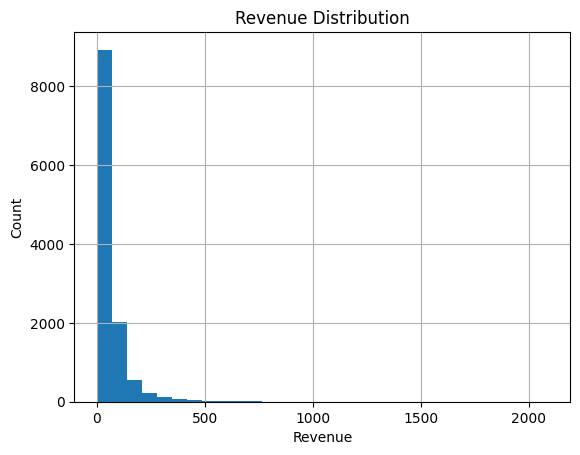

In [ ]:
df['Revenue'].hist(bins=30)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.show()


In [ ]:
print(df['Revenue'].skew())

6.5850544519079905


A positive skewness value indicates a right-skewed distribution, the majority of the data is concentrated on the left. This implies that there are some unusually high revenue values.

Product Price

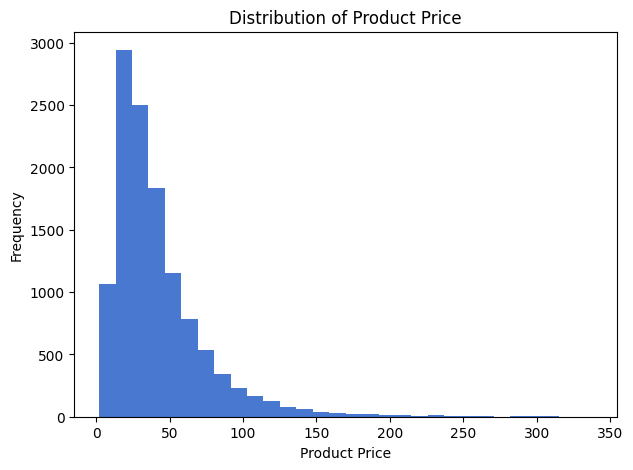

In [ ]:
plt.hist(df['Product_Price'], bins=30)
plt.title("Distribution of Product Price")
plt.xlabel("Product Price")
plt.ylabel("Frequency")
plt.show()


Gender Distribution

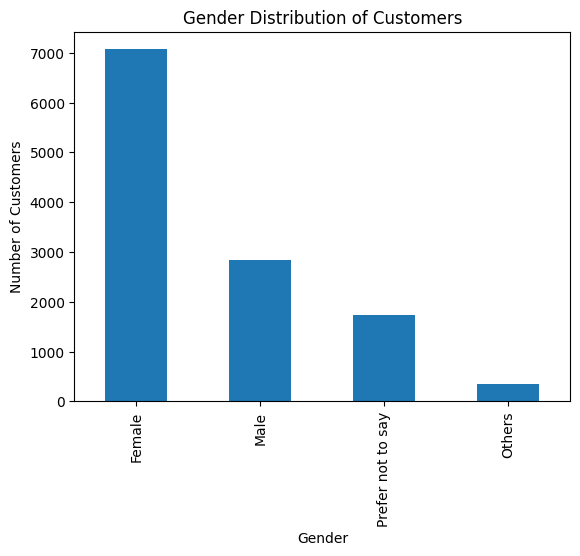

In [5]:
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution of Customers")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()


Product Search Method Distribution

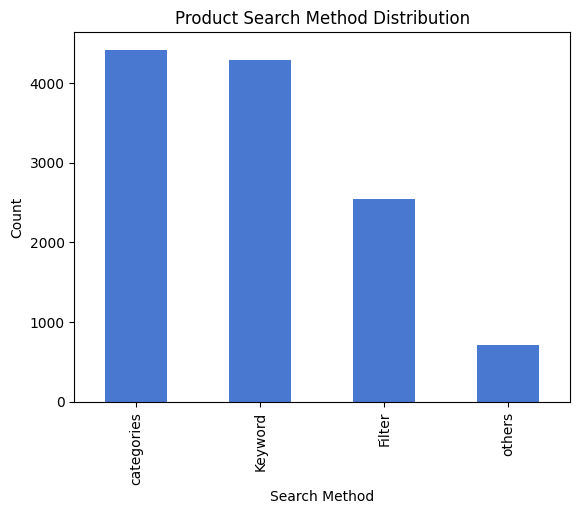

In [ ]:
df['Product_Search_Method'].value_counts().plot(kind='bar')
plt.title("Product Search Method Distribution")
plt.xlabel("Search Method")
plt.ylabel("Count")
plt.show()


Delivery Time

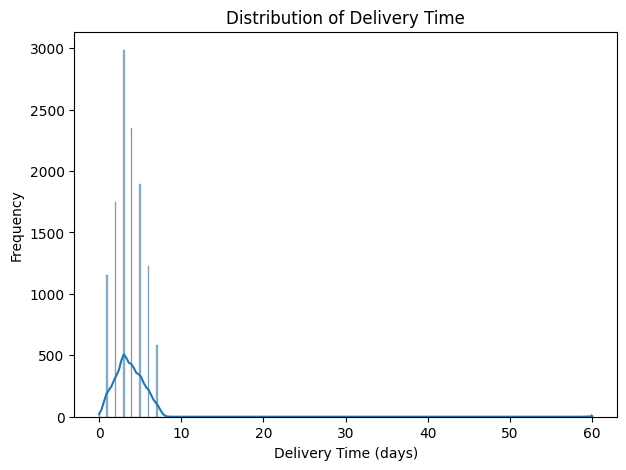

In [6]:
sns.histplot(df['Delivery_Time'], kde=True)
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (days)')
plt.ylabel('Frequency')
plt.show()


Customer Rating

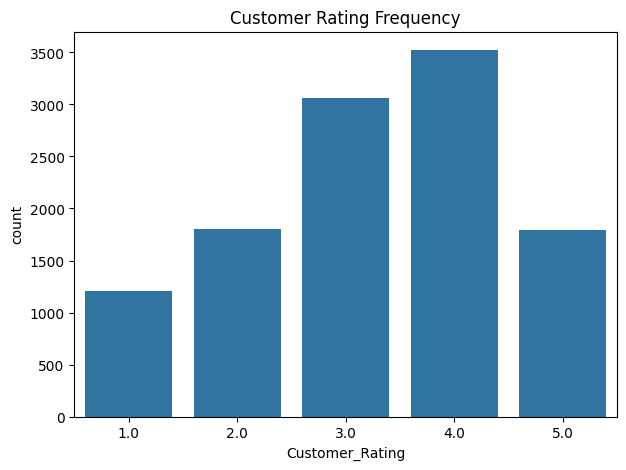

In [10]:
plt.figure(figsize=(7,5))
sns.countplot(x=df['Customer_Rating'], data=df)
plt.title('Customer Rating Frequency')
plt.show()


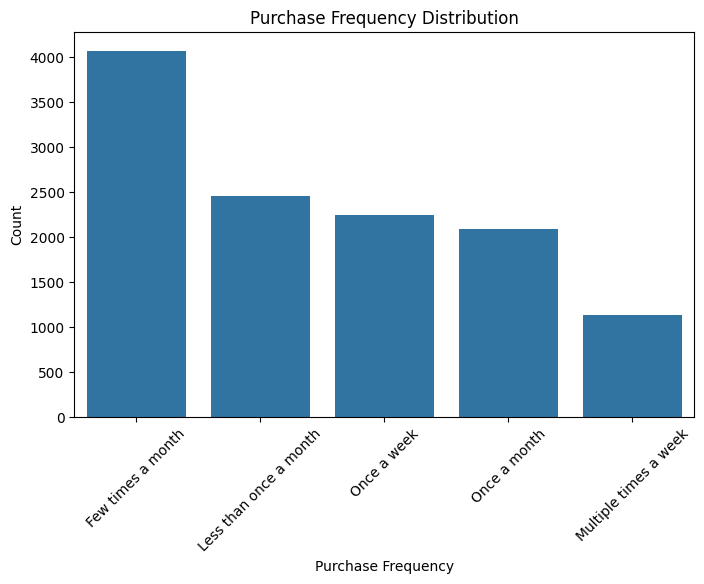

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='Purchase_Frequency',
    data=df,
    order=df['Purchase_Frequency'].value_counts().index
)
plt.title('Purchase Frequency Distribution')
plt.xlabel('Purchase Frequency')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


**BIVARIATE AND MULTIVARIATE ANALYSIS**

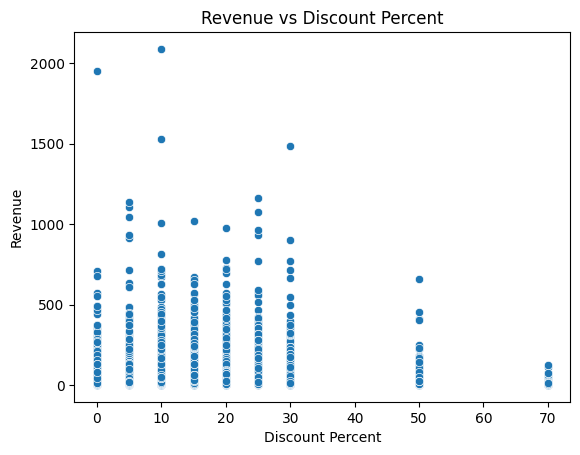

In [13]:
sns.scatterplot(x='Discount_Percent', y='Revenue', data=df)
plt.title('Revenue vs Discount Percent')
plt.xlabel('Discount Percent')
plt.ylabel('Revenue')
plt.show()


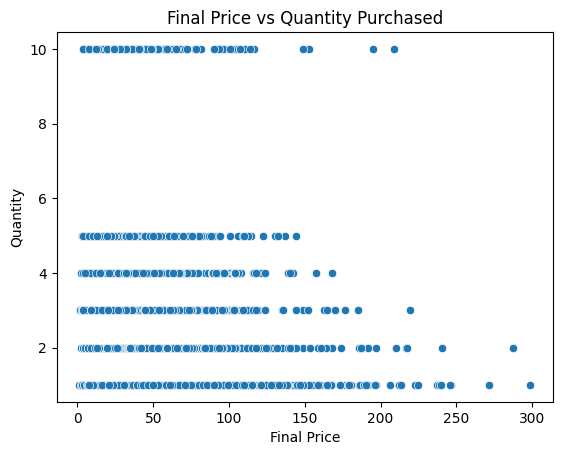

In [14]:
sns.scatterplot(x='Final_Price', y='Quantity', data=df)
plt.title('Final Price vs Quantity Purchased')
plt.xlabel('Final Price')
plt.ylabel('Quantity')
plt.show()


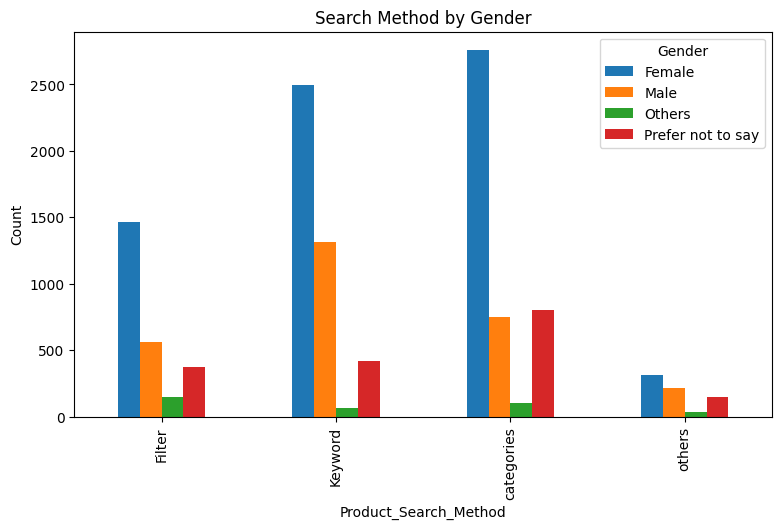

In [20]:
pd.crosstab(df['Product_Search_Method'], df['Gender']).plot(
    kind='bar',
    figsize=(9,5)
)
plt.title('Search Method by Gender')
plt.ylabel('Count')
plt.show()


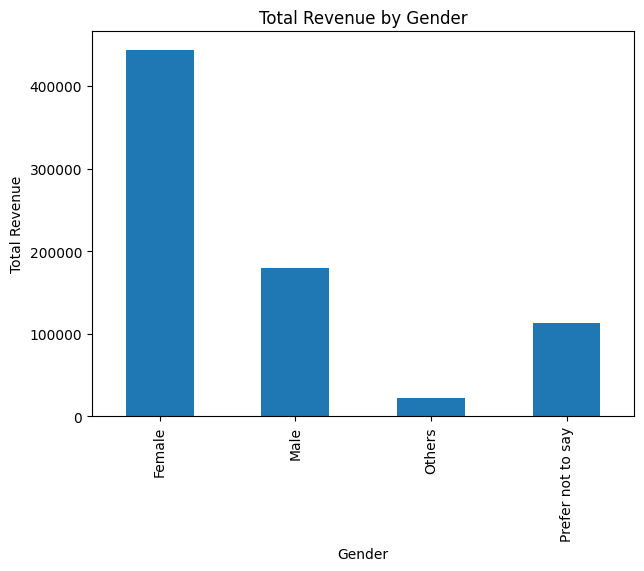

In [30]:
revenue_by_gender = df.groupby('Gender')['Revenue'].sum()

ax = revenue_by_gender.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Total Revenue by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Revenue')
plt.show()


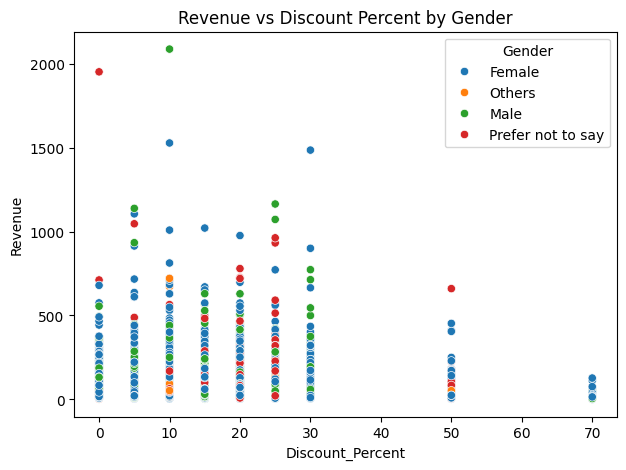

In [16]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='Discount_Percent',
    y='Revenue',
    hue='Gender',
    data=df
)
plt.title('Revenue vs Discount Percent by Gender')
plt.show()


**Correlation Heatmap (multicollinearity)**

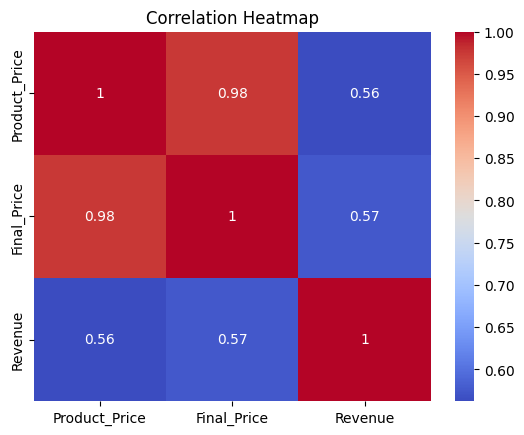

In [ ]:
sns.heatmap(df[['Product_Price','Final_Price','Revenue']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


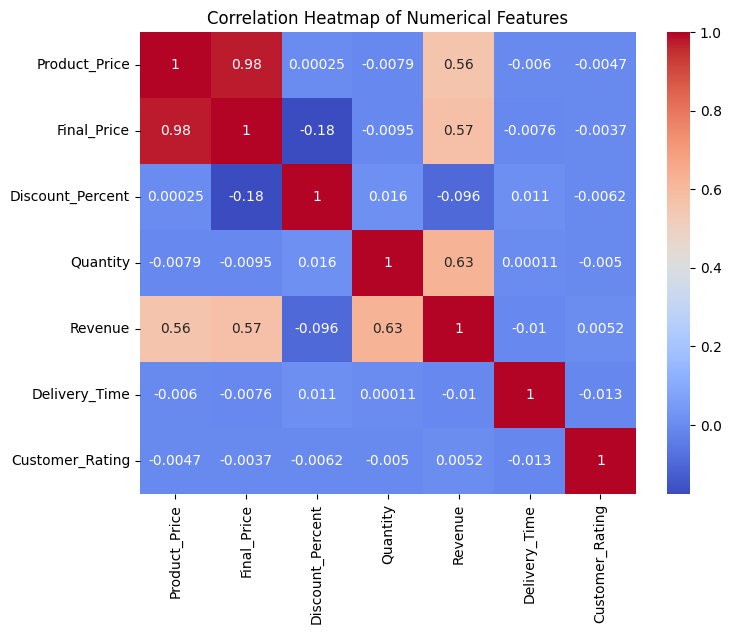

In [5]:
num_cols = [
    'Product_Price',
    'Final_Price',
    'Discount_Percent',
    'Quantity',
    'Revenue',
    'Delivery_Time',
    'Customer_Rating'
]

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


In [ ]:
df_exploded_categories = df.assign(Purchase_Category_Individual=df['Purchase_Categories'].str.split(';'))
df_exploded_categories = df_exploded_categories.explode('Purchase_Category_Individual')
df_exploded_categories['Purchase_Category_Individual'] = df_exploded_categories['Purchase_Category_Individual'].str.strip()

print("Original DataFrame head:")
display(df[['Order_ID', 'Purchase_Categories']].head())

print("\nExploded Categories DataFrame head:")
display(df_exploded_categories[['Order_ID', 'Purchase_Category_Individual']].head())

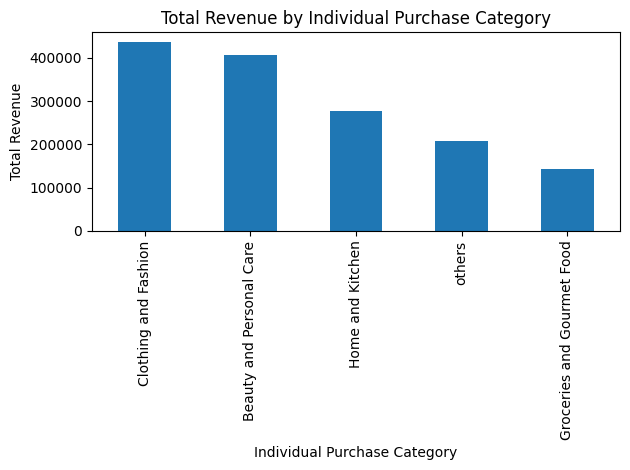

In [ ]:
import matplotlib.pyplot as plt

individual_category_revenue = df_exploded_categories.groupby('Purchase_Category_Individual')['Revenue'].sum().sort_values(ascending=False)
individual_category_revenue.plot(kind='bar')
plt.title('Total Revenue by Individual Purchase Category')
plt.xlabel('Individual Purchase Category')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

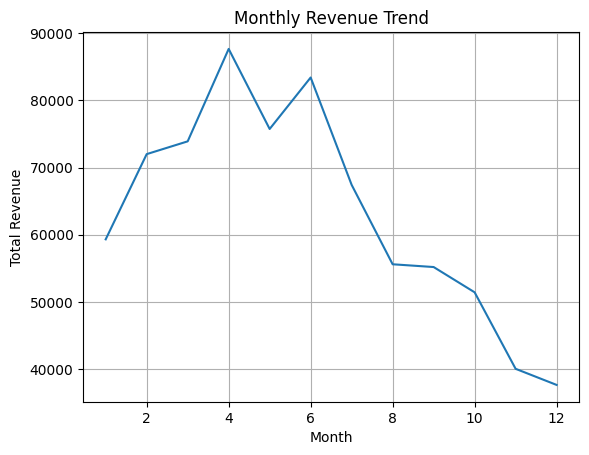

In [4]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='mixed')
df['Month'] = df['Timestamp'].dt.month
df.groupby('Month')['Revenue'].sum().plot(kind='line')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.show()

**BIVARIATE ANALYSIS**


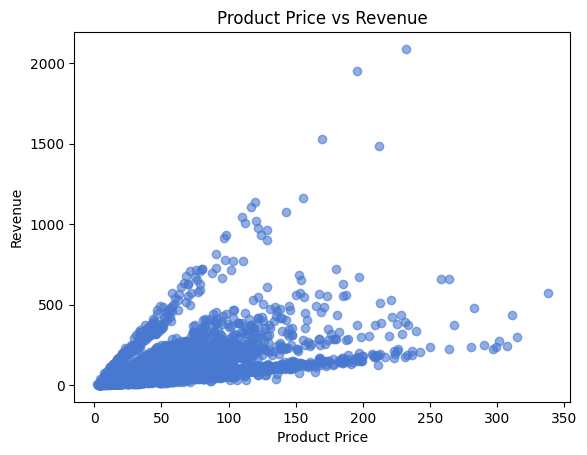

In [ ]:
plt.scatter(df['Product_Price'], df['Revenue'], alpha=0.6)
plt.title("Product Price vs Revenue")
plt.xlabel("Product Price")
plt.ylabel("Revenue")
plt.show()


### **Age Distribution**

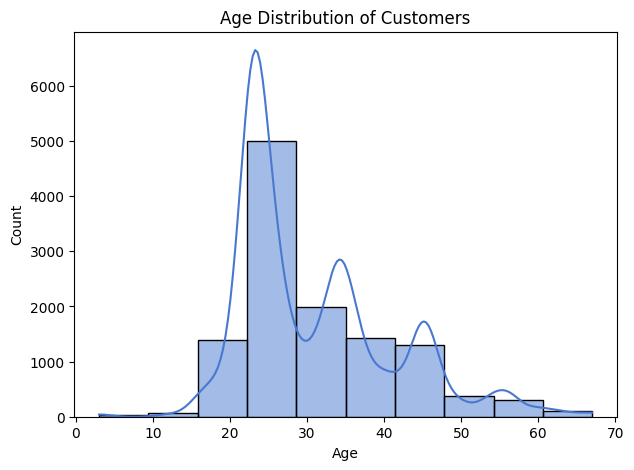

In [ ]:
plt.figure(figsize=(7, 5))
sns.histplot(df['age'],bins=10,kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

**Age vs Revenue**

In [ ]:
bins=[18,25,35,45,55,100]
labels=["18-25","26-35","36-45","46-55","55+"]
df['Age_group']= pd.cut(df['age'],bins=bins , labels =labels,right =False)

In [ ]:

age_revenue = df.groupby('Age_group')['Revenue'].sum()



/tmp/ipython-input-3034499490.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_revenue = df.groupby('Age_group')['Revenue'].sum()


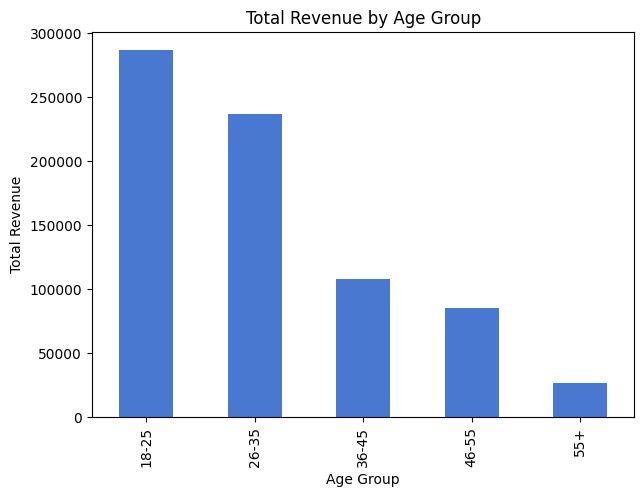

In [ ]:
age_revenue.plot(kind='bar' , figsize=(7,5))
plt.title('Total Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue')
plt.show()

In [ ]:
age_browse_revenue = (
    df.groupby(['Age_group', 'Browsing_Frequency'], observed=True)['Revenue']
    .sum()
    .unstack()
)


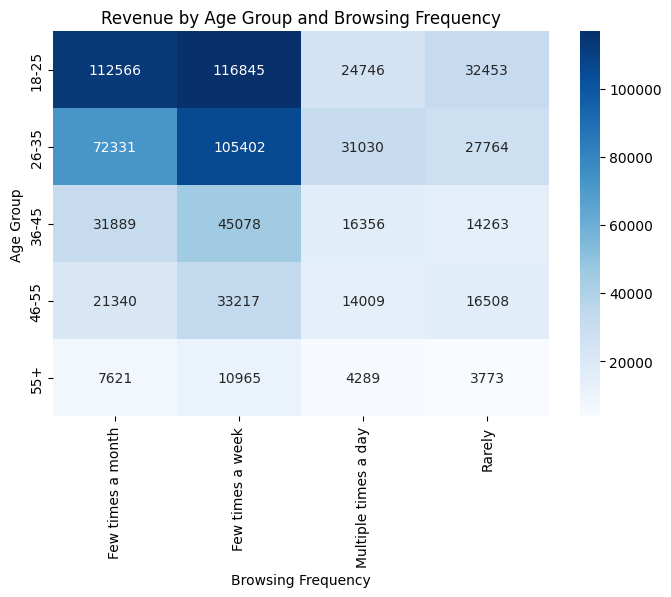

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(age_browse_revenue, annot=True, fmt='.0f', cmap='Blues')
plt.title('Revenue by Age Group and Browsing Frequency')
plt.xlabel('Browsing Frequency')
plt.ylabel('Age Group')
plt.show()


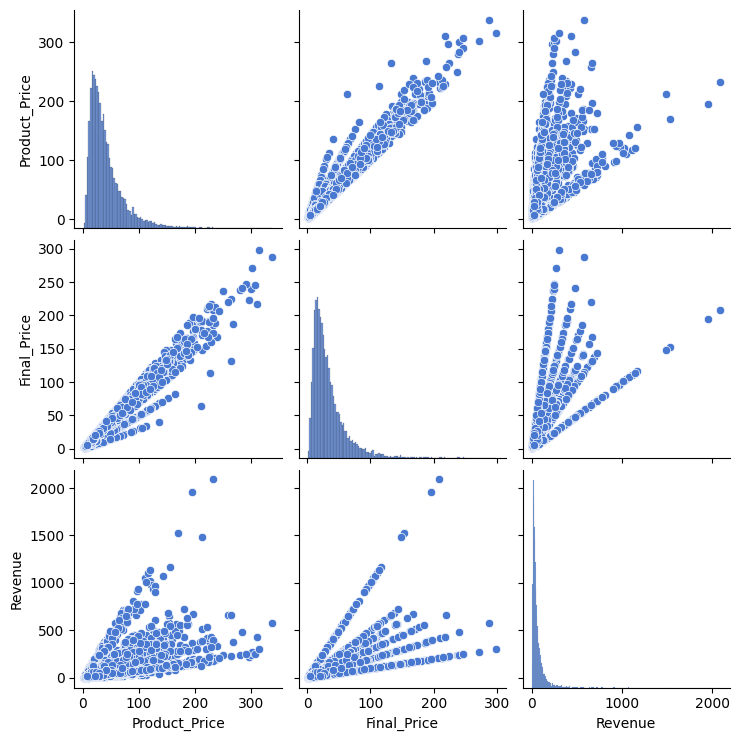

In [ ]:

sns.pairplot(
    df[['Product_Price', 'Final_Price', 'Revenue']],
    diag_kind='hist'
)
plt.show()

In [ ]:
avg_rating = df['Customer_Rating'].mean()
print("Average Customer Rating:", avg_rating)

Average Customer Rating: 3.2558854532677444


In [ ]:
avg_delivery_time = df['Delivery_Time'].mean()
print("Average Delivery Time:", avg_delivery_time)

Average Delivery Time: 3.787916666666667
